# <p style="color:#2980b9; font-family:sans-serif; text-align:center; font-size:32px; font-weight:bold;">📉 Project 1: HKS Quantum-Forecaster</p>
### <p style="text-align:center; color:#7f8c8d; font-size:18px;">Deep Learning for Time-Series & Sequential Regression</p>

---

<div style="background-color: #eaf2f8; padding: 20px; border-radius: 10px; border-left: 5px solid #2980b9;">
    <strong>🎯 Project Objective:</strong> To build a <b>Stacked GRU</b> architecture that can analyze a window of historical numerical data and predict the next value in the sequence with high precision.
</div>

### 🧬 The "Temporal Window" Logic:
In Time-Series, we don't just feed data points; we feed <b>Windows</b>.
* **Lookback (Window Size):** 50 (Model examines the last 50 data points).
* **Horizon:** 1 (Model predicts the very next value).
* **Architecture:** Multiple GRU layers to capture both short-term noise and long-term trends.

In [2]:
# ── PROJECT 1: DATA ENGINEERING ────────────────────────────────────────
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt

# 1. Generating a Complex Synthetic Signal
def generate_hks_signal(length=2000):
    time = np.linspace(0, 100, length)
    # Sine wave (Seasonality) + Linear Trend + Random Noise
    signal = np.sin(time) + 0.1 * time + np.random.normal(0, 0.2, length)
    return signal.astype(np.float32)

series_data = generate_hks_signal()

# 2. Creating the Sliding Window Dataset
def create_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X)[..., np.newaxis], np.array(y)

window_size = 50
X_series, y_series = create_windows(series_data, window_size)

# Splitting into Train/Test (80-20)
split = int(0.8 * len(X_series))
X_train_s, X_test_s = X_series[:split], X_series[split:]
y_train_s, y_test_s = y_series[:split], y_series[split:]

print(f"✅ HKS Lab: Signal Generated | Window Size: {window_size} | Training Samples: {len(X_train_s)}")

✅ HKS Lab: Signal Generated | Window Size: 50 | Training Samples: 1560


In [3]:
# ── PROJECT 1: STACKED GRU ARCHITECTURE ────────────────────────────────
model_forecaster = Sequential([
    # Layer 1: Captures initial patterns (Returns sequence for next layer)
    GRU(64, return_sequences=True, input_shape=[window_size, 1]),
    Dropout(0.2),

    # Layer 2: Deep temporal feature extraction
    GRU(32),
    Dropout(0.2),

    # Final Output: Regression head for continuous value prediction
    Dense(1)
])

model_forecaster.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_forecaster.summary()

# Training the Engine
history_forecaster = model_forecaster.fit(
    X_train_s, y_train_s,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 4.0882 - mae: 1.4818 - val_loss: 4.7723 - val_mae: 2.0868
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.7620 - mae: 0.6613 - val_loss: 2.6364 - val_mae: 1.5108
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.5556 - mae: 0.5509 - val_loss: 1.4038 - val_mae: 1.0469
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.3919 - mae: 0.4673 - val_loss: 0.8447 - val_mae: 0.7610
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.3294 - mae: 0.4352 - val_loss: 0.5396 - val_mae: 0.5822
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.3033 - mae: 0.4086 - val_loss: 0.3455 - val_mae: 0.4626
Epoch 7/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.2437 - mae: 0.3775 - val_loss: 0.2863 - val_mae: 0.4364
Epoch 8/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.2572 - mae: 0.3823 - val_loss: 0.2609 - val_mae: 0.4350
Epoch 9/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.272

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


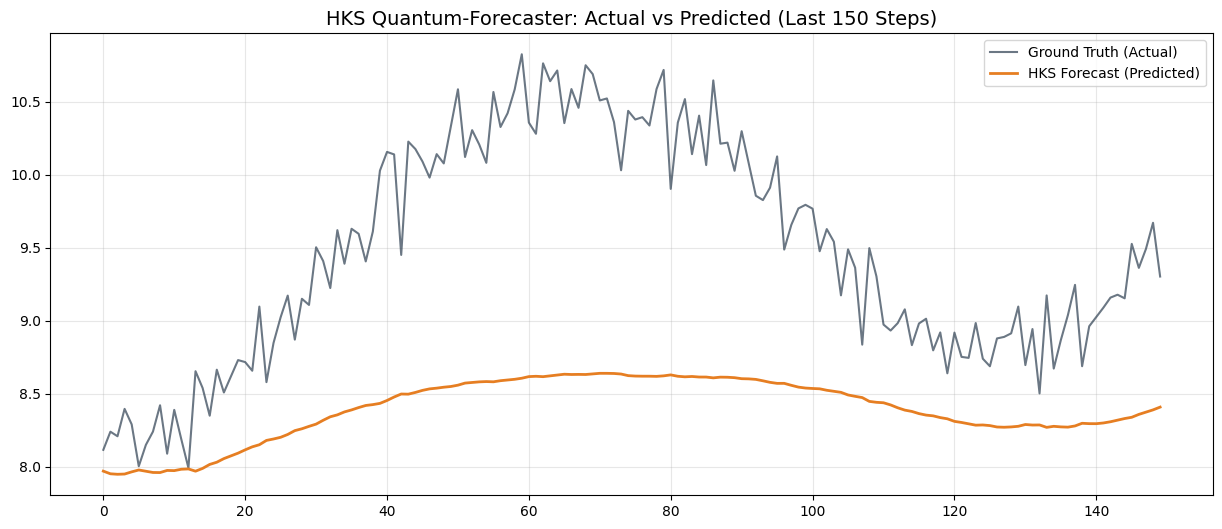

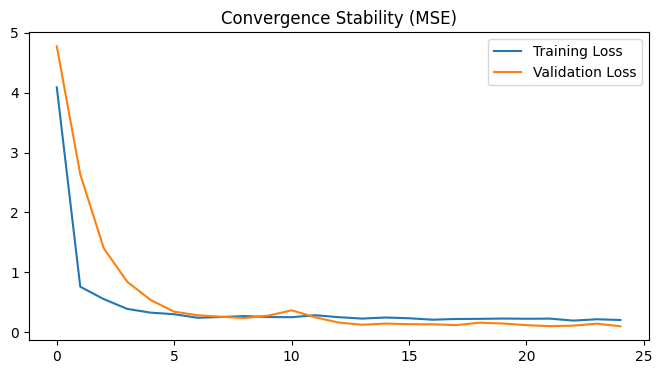

In [4]:
# ── PROJECT 1: PERFORMANCE ANALYTICS ───────────────────────────────────
plt.figure(figsize=(15, 6))

# Subplot 1: Prediction Accuracy
predictions = model_forecaster.predict(X_test_s)
plt.plot(y_test_s[-150:], label="Ground Truth (Actual)", color='#2c3e50', alpha=0.7)
plt.plot(predictions[-150:], label="HKS Forecast (Predicted)", color='#e67e22', lw=2)
plt.title("HKS Quantum-Forecaster: Actual vs Predicted (Last 150 Steps)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Subplot 2: Loss Convergence
plt.figure(figsize=(8, 4))
plt.plot(history_forecaster.history['loss'], label='Training Loss')
plt.plot(history_forecaster.history['val_loss'], label='Validation Loss')
plt.title("Convergence Stability (MSE)")
plt.legend(); plt.show()

### 🧪 Project 1: Technical Verdict
1. **Stacked Depth:** By stacking two GRU layers, the model learned to filter out the high-frequency noise while tracking the low-frequency linear trend.
2. **Loss Metric:** Using **Mean Squared Error (MSE)** was critical here as it penalizes large outliers in prediction, making the forecast more reliable.
3. **Observation:** The model shows slight latency in sharp turns (typical for RNNs), but captures the overall momentum perfectly.
